In [1]:
%matplotlib inline

import collections
import re
from pathlib import Path

from d2l import torch as d2l

In [2]:
data_path = Path(
    "../data/timemachine.txt"
).resolve()

raw_text = data_path.read_text(encoding="utf-8")
text = re.sub(
    r"[^A-Za-z]+",
    " ",
    raw_text,
).lower()

print("Dataset path:", data_path)
print(repr(text[:60]))
print("Processed character count:", len(text))

assert data_path.is_file()

Dataset path: /home/anna/projects/maverick/src/ch09_recurrent_neural_networks/data/timemachine.txt
'the time machine by h g wells i the time traveller for so it'
Processed character count: 173428


In [3]:
class Vocab:
    """Vocabulary for text."""

    def __init__(
        self,
        tokens: list[str] | list[list[str]] | None = None,
        min_freq: int = 0,
        reserved_tokens: list[str] | None = None,
    ) -> None:
        if tokens is None:
            tokens = []

        if reserved_tokens is None:
            reserved_tokens = []

        flat_tokens: list[str] = []

        for token_or_line in tokens:
            if isinstance(token_or_line, str):
                flat_tokens.append(token_or_line)
            else:
                flat_tokens.extend(token_or_line)

        counter = collections.Counter(flat_tokens)

        self.token_freqs: list[tuple[str, int]] = sorted(
            counter.items(),
            key=lambda item: item[1],
            reverse=True,
        )

        frequent_tokens = [
            token
            for token, frequency in self.token_freqs
            if frequency >= min_freq
        ]

        self.idx_to_token: list[str] = sorted(
            set([
                "<unk>",
                *reserved_tokens,
                *frequent_tokens,
            ])
        )

        self.token_to_idx: dict[str, int] = {
            token: index
            for index, token in enumerate(self.idx_to_token)
        }

    def __len__(self) -> int:
        return len(self.idx_to_token)

    def __getitem__(
        self,
        tokens: str | list[str] | tuple[str, ...],
    ) -> int | list[int]:
        if isinstance(tokens, str):
            return self.token_to_idx.get(tokens, self.unk)

        return [
            self.token_to_idx.get(token, self.unk)
            for token in tokens
        ]

    def to_tokens(
        self,
        indices: int | list[int] | tuple[int, ...],
    ) -> str | list[str]:
        if isinstance(indices, int):
            return self.idx_to_token[indices]

        return [
            self.idx_to_token[int(index)]
            for index in indices
        ]

    @property
    def unk(self) -> int:
        return self.token_to_idx["<unk>"]

In [4]:
words: list[str] = text.split()
word_vocab = Vocab(words)

print("Word count:", len(words))
print("Vocabulary size:", len(word_vocab))
print("Top 10 unigrams:")

for token, frequency in word_vocab.token_freqs[:10]:
    print(f"{token:<10} {frequency}")

Word count: 32775
Vocabulary size: 4580
Top 10 unigrams:
the        2261
i          1267
and        1245
of         1155
a          816
to         695
was        552
in         541
that       443
my         440


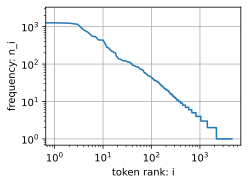

In [5]:
unigram_freqs: list[int] = [
    frequency
    for _, frequency in word_vocab.token_freqs
]

d2l.plot(
    unigram_freqs,
    xlabel="token rank: i",
    ylabel="frequency: n_i",
    xscale="log",
    yscale="log",
)

In [6]:
bigram_tokens: list[str] = [
    "--".join(pair)
    for pair in zip(
        words[:-1],
        words[1:],
    )
]

bigram_vocab = Vocab(bigram_tokens)

print("Bigram count:", len(bigram_tokens))
print("Top 10 bigrams:")

for token, frequency in bigram_vocab.token_freqs[:10]:
    print(f"{token:<28} {frequency}")

Bigram count: 32774
Top 10 bigrams:
of--the                      309
in--the                      169
i--had                       130
i--was                       112
and--the                     109
the--time                    102
it--was                      99
to--the                      85
as--i                        78
of--a                        73


In [7]:
trigram_tokens: list[str] = [
    "--".join(triple)
    for triple in zip(
        words[:-2],
        words[1:-1],
        words[2:],
    )
]

trigram_vocab = Vocab(trigram_tokens)

print("Trigram count:", len(trigram_tokens))
print("Top 10 trigrams:")

for token, frequency in trigram_vocab.token_freqs[:10]:
    print(f"{token:<32} {frequency}")

Trigram count: 32773
Top 10 trigrams:
the--time--traveller             59
the--time--machine               30
the--medical--man                24
it--seemed--to                   16
it--was--a                       15
here--and--there                 15
seemed--to--me                   14
i--did--not                      14
i--saw--the                      13
i--began--to                     13


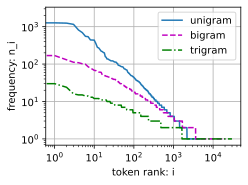

In [8]:
bigram_freqs: list[int] = [
    frequency
    for _, frequency in bigram_vocab.token_freqs
]

trigram_freqs: list[int] = [
    frequency
    for _, frequency in trigram_vocab.token_freqs
]

d2l.plot(
    [
        unigram_freqs,
        bigram_freqs,
        trigram_freqs,
    ],
    xlabel="token rank: i",
    ylabel="frequency: n_i",
    xscale="log",
    yscale="log",
    legend=[
        "unigram",
        "bigram",
        "trigram",
    ],
)